In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
df1 = pd.read_csv("../data/raw/intent_taxonomy.csv")
df2 = pd.read_csv("../data/raw/support_messages.csv")

In [3]:
df1.head(10)

,intent,description,priority,target_response_minutes
0,balance_enquiry,balance enquiry,normal,240
1,failed_transfer,failed transfer,high,60
2,tariff_question,tariff question,normal,240
3,app_technical,app technical,normal,240
4,pin_reset,pin reset,normal,240
5,account_opening,account opening,normal,240
6,agent_complaint,agent complaint,high,60
7,card_request,card request,normal,240
8,praise,praise,normal,240
9,fraud_report,fraud report,critical,15


In [4]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   intent                   10 non-null     object
 1   description              10 non-null     object
 2   priority                 10 non-null     object
 3   target_response_minutes  10 non-null     int64 
dtypes: int64(1), object(3)
memory usage: 452.0+ bytes


In [5]:
df1.describe()

,target_response_minutes
count,10.000000
mean,181.500000
std,94.986841
min,15.000000
25%,105.000000
50%,240.000000
75%,240.000000
max,240.000000


In [6]:
df2.tail()

,message_id,received_at,channel,message_text,language_hint,customer_tier,intent,resolved_minutes
44595,MSG-011843,06/10/2025 15:54,app chat,good morning how much i get for ma account ver...,mixed,plus,balance_enquiry,11
44596,MSG-001805,2026-01-17 10:25:00,whatsapp,hi the app says network error pls,en,plus,app_technical,50
44597,MSG-002035,2025-12-12 18:46:00,whatsapp,pls abeg check ma balance check my balance pls...,mixed,basic,balance_enquiry,58
44598,MSG-035244,2026-02-09 18:20:00,whatsapp,hello how much be di charge for send money que...,mixed,basic,tariff_question,155
44599,MSG-013719,2026-01-10 10:18:00,app chat,je n'ai pas autorise cette transaction asap,fr,basic,fraud_report,224


In [7]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44600 entries, 0 to 44599
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   message_id        44600 non-null  object
 1   received_at       44600 non-null  object
 2   channel           44600 non-null  object
 3   message_text      44600 non-null  object
 4   language_hint     44600 non-null  object
 5   customer_tier     44600 non-null  object
 6   intent            44600 non-null  object
 7   resolved_minutes  44600 non-null  int64 
dtypes: int64(1), object(7)
memory usage: 2.7+ MB


In [8]:
intents_counts = df2.groupby("intent").count()

In [9]:
intents_counts

,message_id,received_at,channel,message_text,language_hint,customer_tier,resolved_minutes
intent,,,,,,,
account_opening,3594,3594,3594,3594,3594,3594,3594
agent_complaint,3225,3225,3225,3225,3225,3225,3225
app_technical,5327,5327,5327,5327,5327,5327,5327
balance_enquiry,10309,10309,10309,10309,10309,10309,10309
card_request,2362,2362,2362,2362,2362,2362,2362
failed_transfer,7327,7327,7327,7327,7327,7327,7327
fraud_report,1026,1026,1026,1026,1026,1026,1026
pin_reset,4725,4725,4725,4725,4725,4725,4725
praise,1083,1083,1083,1083,1083,1083,1083


C:\Users\chris\AppData\Local\Temp\ipykernel_1612\1848942653.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


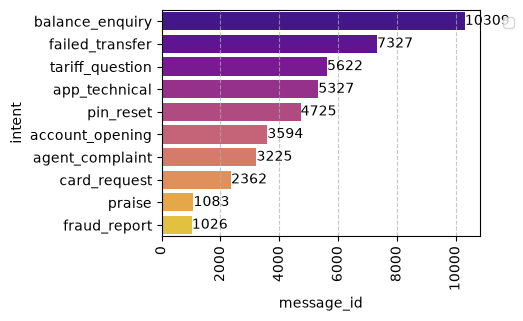

In [10]:
plt.figure(figsize=(5, 3))
ax = sns.barplot(
    data=intents_counts.sort_values(by="message_id", ascending=False),
    x="message_id",
    y="intent",
    hue="intent",
    dodge=False,
    palette="plasma",
)
plt.tight_layout()

plt.xticks(rotation=90)
ax.legend(*plt.gca().get_legend_handles_labels())
ax.grid(axis="x", linestyle="--", alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_width())}",
        (p.get_width(), p.get_y() + p.get_height() / 2),
        ha="left",
        va="center",
    )

In [ ]:
duplicates = df2[df2.message_text.duplicated(keep=False)].sort_values(by="message_text")
duplicates_df = (
    duplicates.groupby("message_text", as_index=False)["intent"]
    .apply(set)
    .reset_index()
)

In [12]:
duplicates_df.head()

,index,message_text,intent
0,0,see transaction i no expect,{failed_transfer}
1,1,be debited but i no sabi why,{failed_transfer}
2,2,get problem,"{app_technical, card_request, balance_enquiry,..."
3,3,need assistance,"{tariff_question, app_technical, pin_reset}"
4,4,see transaction i no expect,"{failed_transfer, fraud_report}"


In [13]:
duplicates_df[duplicates_df["intent"].apply(len) > 1]

,index,message_text,intent
2,2,get problem,"{app_technical, card_request, balance_enquiry,..."
3,3,need assistance,"{tariff_question, app_technical, pin_reset}"
4,4,see transaction i no expect,"{failed_transfer, fraud_report}"
5,5,'est quoi ca,"{tariff_question, app_technical}"
6,6,ABEG HELP,"{card_request, praise, failed_transfer, pin_re..."
...,...,...,...
4842,4842,wwetin dey happen,"{failed_transfer, card_request, praise, balanc..."
4843,4843,y a t il des frais de retrait,"{tariff_question, failed_transfer}"
4845,4845,y a t il des frais de retrait,"{tariff_question, balance_enquiry}"
4851,4851,y a t il des frais de retrait how much is the ...,"{tariff_question, pin_reset}"


In [14]:
df2.groupby("language_hint")["message_id"].count()

language_hint
en       14621
fr       12735
mixed     9980
pi        7264
Name: message_id, dtype: int64

In [15]:
df2.groupby("intent").sample(n=10).to_csv("../data/raw/hand_classified_sample.csv")

In [21]:
df3 = pd.read_csv("../data/raw/hand_classified_sample.csv", index_col=0)
df3.head()

,message_id,received_at,channel,message_text,language_hint,customer_tier,intent,resolved_minutes
19092,MSG-022158,2025-10-26 19:44:00,whatsapp,hi comment ouvrir un compte pls,fr,plus,account_opening,129
22027,MSG-006437,2026-01-19 10:06:00,facebook,helloo je veux creer un compte,fr,premium,account_opening,160
42571,MSG-025229,2026-05-22 10:59:00,app chat,comment ouvrir un compe 🙏,fr,premium,account_opening,73
9492,MSG-021379,2026-06-07 19:56:00,call centre note,abeg help,en,basic,account_opening,34
18145,MSG-022961,2025-12-12 16:33:00,whatsapp,commnt ouvrir un compte what documents d...,mixed,basic,account_opening,57


In [17]:
df3.isna().sum()

message_id          0
received_at         0
channel             0
message_text        0
language_hint       0
customer_tier       0
intent              0
resolved_minutes    0
dtype: int64

In [20]:
df3.query("hand_classified.isna() == False and hand_classified != intent").count()

UndefinedVariableError: name 'hand_classified' is not defined

In [ ]:
df3.query("hand_classified.isna()").message_text

39957                  assistance svp
26706                              hi
42177                    help me abeg
22127                     una help me
28265        bonjour  j'ai  un  souci
30324            BONJOUR JAI UN SOUCI
37324                          urgent
32767        good morning i get issue
1913      please i need help urgently
15633    pllease i need help urgently
36169                  i get probllem
5480                           hello?
41349              there is a problem
1856                    una help me ?
21582                  assistance svp
22169                       abeg help
2335                      una help me
Name: message_text, dtype: object

In [ ]:
df2.loc[39956:]

,message_id,received_at,channel,message_text,language_hint,customer_tier,intent,resolved_minutes
39956,MSG-030781,2025-12-31 03:57:00,call centre note,slt l'agent m'a fait payer un supplement thanks,fr,basic,agent_complaint,62
39957,MSG-009555,2026-05-12 04:20:00,facebook,assistance svp,en,premium,agent_complaint,1
39958,MSG-034989,2025-11-23 04:12:00,facebook,pls le transfert est en attente depuis hier,fr,basic,failed_transfer,159
39959,MSG-038952,2025-11-16 18:48:00,facebook,hello i don forget ma pin asap,pi,basic,pin_reset,1
39960,MSG-031336,2025-11-06 01:46:00,whatsapp,hello abeg reset ma code j'ai oublie mon code 🙏,mixed,premium,pin_reset,156
...,...,...,...,...,...,...,...,...
44595,MSG-011843,06/10/2025 15:54,app chat,good morning how much i get for ma account ver...,mixed,plus,balance_enquiry,11
44596,MSG-001805,2026-01-17 10:25:00,whatsapp,hi the app says network error pls,en,plus,app_technical,50
44597,MSG-002035,2025-12-12 18:46:00,whatsapp,pls abeg check ma balance check my balance pls...,mixed,basic,balance_enquiry,58
44598,MSG-035244,2026-02-09 18:20:00,whatsapp,hello how much be di charge for send money que...,mixed,basic,tariff_question,155
